In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('Huawei_Weekly_4G.csv')
df.head()

C:\Users\hkizamou\AppData\Local\Temp\ipykernel_9152\2129260626.py:1: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Huawei_Weekly_4G.csv')


,Date,eNodeB Name,Frequency band,Cell FDD TDD Indication,Cell Name,LocalCell Id,eNodeB Function Name,Integrity,LTE_CSSR RATE without VOLTE_REC,4G/LTE Drop Call Rate (without VoLTE)_V7,Ave 4G/LTE DL User Thrput (ALL) (kbit/s)(kbit/s),4G/LTE UL Traffic Volume_REC (GBytes),4G/LTE UL User Thrput (ALL) (kbps)_REC,LTE DL Traffic Volume_REC (GBytes),L.Traffic.ActiveUser.Dl.Avg,L.Traffic.ActiveUser.Ul.Avg,4GHW_ Average PRB Usage DL,4GHW_ Average PRB Usage UL,L.Traffic.User.Avg
0,2024-06-24,0001_KKO_KATI_SRAN_FO_GE_GE,20,CELL_FDD,0001_KKO_KATI_3_L800,13,0001_KKO_KATI_4G,100%,99.153,0.9521,5073.3543,50.0301,2138.9469,430.5229,1.8903,1.5624,49.2775,15.0372,26.8633
1,2024-06-24,0001_KKO_KATI_SRAN_FO_GE_GE,20,CELL_FDD,0001_KKO_KATI_2_L800,12,0001_KKO_KATI_4G,100%,99.2467,0.7676,7780.4102,76.9562,2692.6332,602.8924,1.9331,1.7797,49.6515,16.8396,31.6133
2,2024-06-24,0001_KKO_KATI_SRAN_FO_GE_GE,20,CELL_FDD,0001_KKO_KATI_1_L800,11,0001_KKO_KATI_4G,100%,98.3222,0.8999,11319.2687,19.8155,2667.5161,151.2647,0.3966,0.4801,18.7620,7.9541,7.0259
3,2024-06-24,401_KAYES_SRAN_GE_GE,20,CELL_FDD,0401_KYS_KAY-LEGAL-SEGOU_3_L800,13,0401_KYS_KAY-LEGAL-SEGOU_4G,100%,99.6316,0.0715,19811.7165,54.3573,3796.2934,445.4982,0.6054,0.5256,26.4108,13.0305,11.9333
4,2024-06-24,401_KAYES_SRAN_GE_GE,20,CELL_FDD,0401_KYS_KAY-LEGAL-SEGOU_2_L800,12,0401_KYS_KAY-LEGAL-SEGOU_4G,100%,99.5652,0.1088,15052.5273,34.5930,3988.0178,332.7645,0.5842,0.3494,19.2749,9.9659,11.0457


# Data Cleaning

In [3]:
# Renaming Attributes
df.rename(columns={'LTE_CSSR RATE without VOLTE_REC':'CSSR (wo VoLTE)',
                   '4G/LTE Drop Call Rate (without VoLTE)_V7':'DRC (wo VoLTE)',
                   'Ave 4G/LTE DL User Thrput (ALL) (kbit/s)(kbit/s)':'Avg DL User Thrput (kbps)',
                   '4G/LTE UL Traffic Volume_REC (GBytes)':'UL Traffic Volume (GBytes)',
                   '4G/LTE UL User Thrput (ALL) (kbps)_REC':'Avg UL User Thrput (kbps)',
                   'LTE DL Traffic Volume_REC (GBytes)':'DL Traffic Volume (GBytes)',
                   'L.Traffic.ActiveUser.Dl.Avg':'Avg DL Traffic Active User',
                   'L.Traffic.ActiveUser.Ul.Avg':'Avg UL Traffic Active User',
                   '4GHW_ Average PRB Usage DL':'Avg DL PRB Usage',
                   '4GHW_ Average PRB Usage UL':'Avg UL PRB Usage',
                   'L.Traffic.User.Avg':'Avg Traffic User'}, inplace=True)

df.head()

,Date,eNodeB Name,Frequency band,Cell FDD TDD Indication,Cell Name,LocalCell Id,eNodeB Function Name,Integrity,CSSR (wo VoLTE),DRC (wo VoLTE),Avg DL User Thrput (kbps),UL Traffic Volume (GBytes),Avg UL User Thrput (kbps),DL Traffic Volume (GBytes),Avg DL Traffic Active User,Avg UL Traffic Active User,Avg DL PRB Usage,Avg UL PRB Usage,Avg Traffic User
0,2024-06-24,0001_KKO_KATI_SRAN_FO_GE_GE,20,CELL_FDD,0001_KKO_KATI_3_L800,13,0001_KKO_KATI_4G,100%,99.153,0.9521,5073.3543,50.0301,2138.9469,430.5229,1.8903,1.5624,49.2775,15.0372,26.8633
1,2024-06-24,0001_KKO_KATI_SRAN_FO_GE_GE,20,CELL_FDD,0001_KKO_KATI_2_L800,12,0001_KKO_KATI_4G,100%,99.2467,0.7676,7780.4102,76.9562,2692.6332,602.8924,1.9331,1.7797,49.6515,16.8396,31.6133
2,2024-06-24,0001_KKO_KATI_SRAN_FO_GE_GE,20,CELL_FDD,0001_KKO_KATI_1_L800,11,0001_KKO_KATI_4G,100%,98.3222,0.8999,11319.2687,19.8155,2667.5161,151.2647,0.3966,0.4801,18.7620,7.9541,7.0259
3,2024-06-24,401_KAYES_SRAN_GE_GE,20,CELL_FDD,0401_KYS_KAY-LEGAL-SEGOU_3_L800,13,0401_KYS_KAY-LEGAL-SEGOU_4G,100%,99.6316,0.0715,19811.7165,54.3573,3796.2934,445.4982,0.6054,0.5256,26.4108,13.0305,11.9333
4,2024-06-24,401_KAYES_SRAN_GE_GE,20,CELL_FDD,0401_KYS_KAY-LEGAL-SEGOU_2_L800,12,0401_KYS_KAY-LEGAL-SEGOU_4G,100%,99.5652,0.1088,15052.5273,34.5930,3988.0178,332.7645,0.5842,0.3494,19.2749,9.9659,11.0457


In [4]:
df.isnull().sum()

Date                             0
eNodeB Name                      0
Frequency band                   0
Cell FDD TDD Indication          0
Cell Name                        0
LocalCell Id                     0
eNodeB Function Name             0
Integrity                        0
CSSR (wo VoLTE)                  0
DRC (wo VoLTE)                6138
Avg DL User Thrput (kbps)     4397
UL Traffic Volume (GBytes)       0
Avg UL User Thrput (kbps)     4344
DL Traffic Volume (GBytes)       0
Avg DL Traffic Active User       0
Avg UL Traffic Active User       0
Avg DL PRB Usage              4096
Avg UL PRB Usage              4096
Avg Traffic User                 0
dtype: int64

<Axes: >

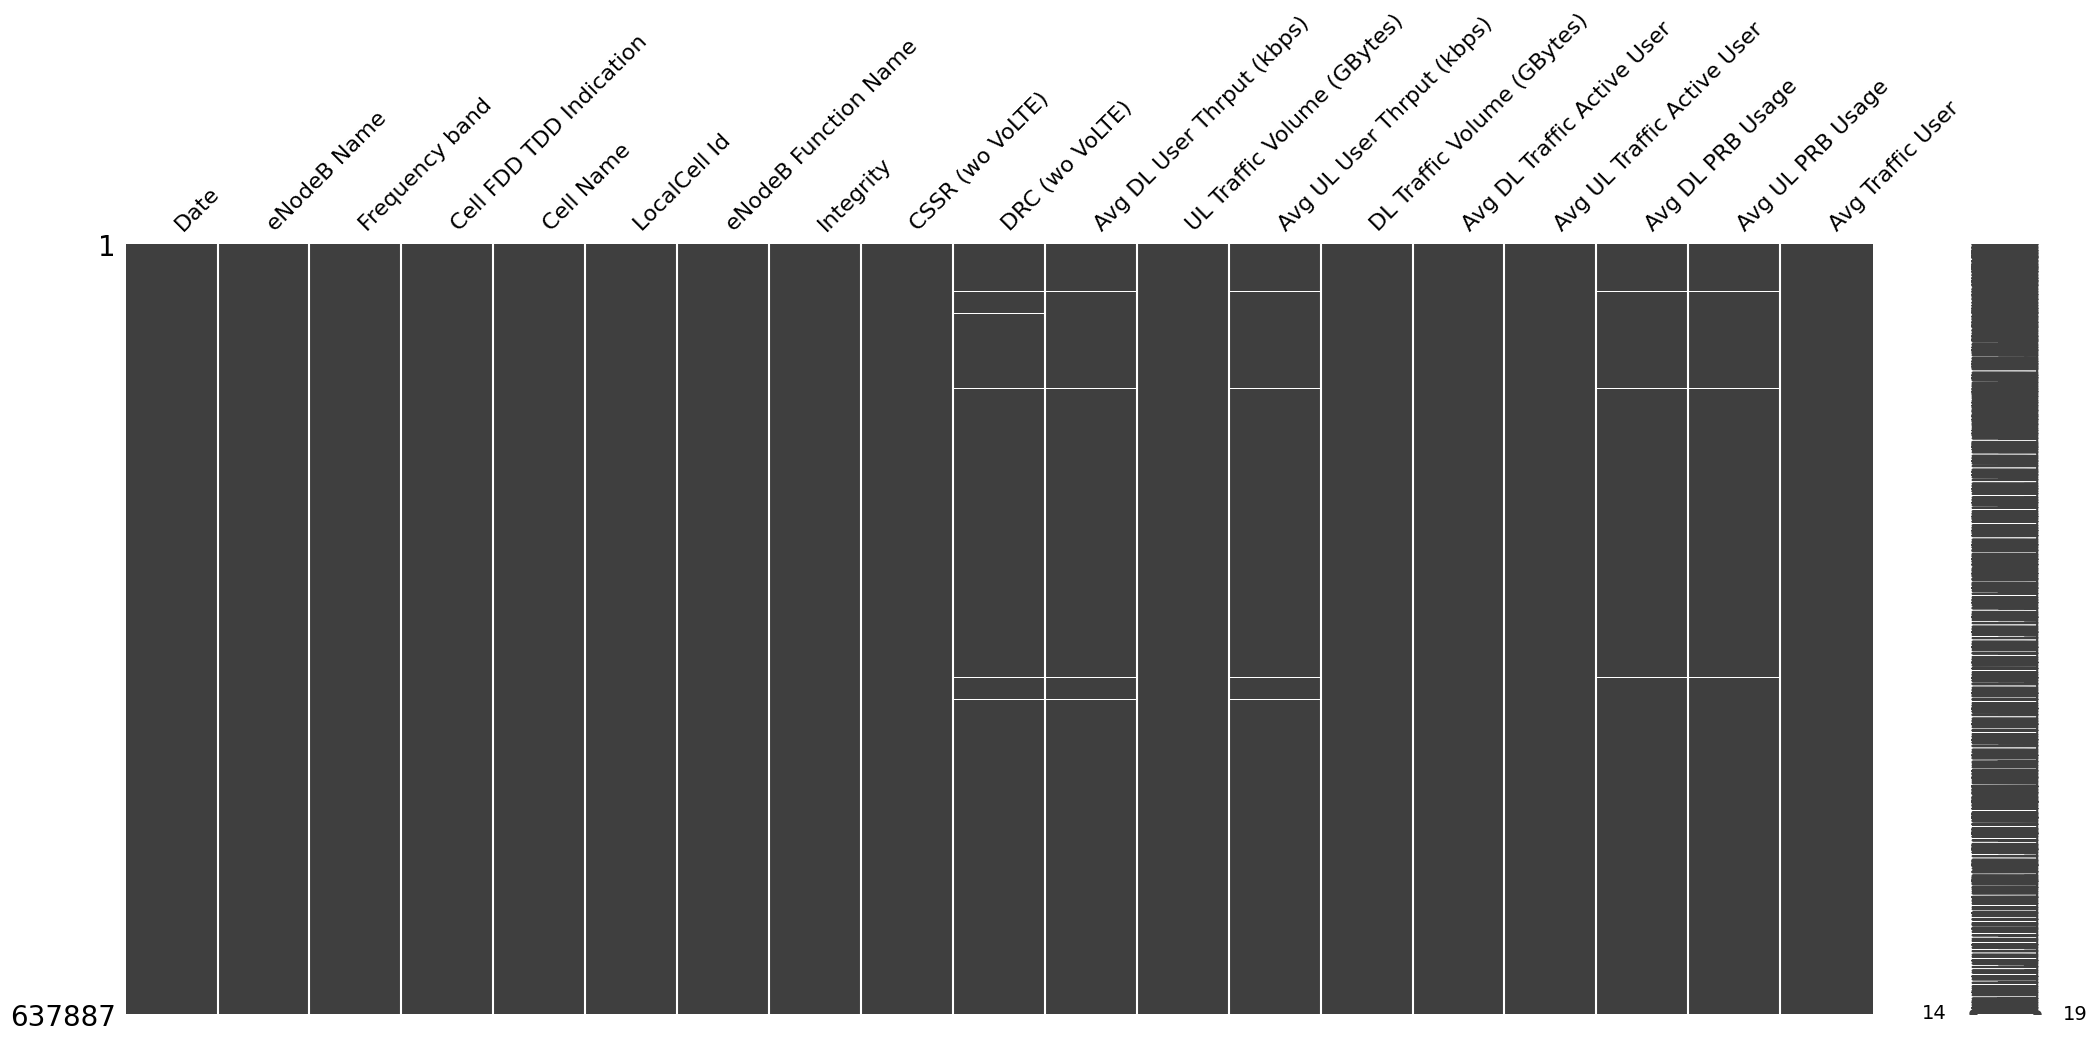

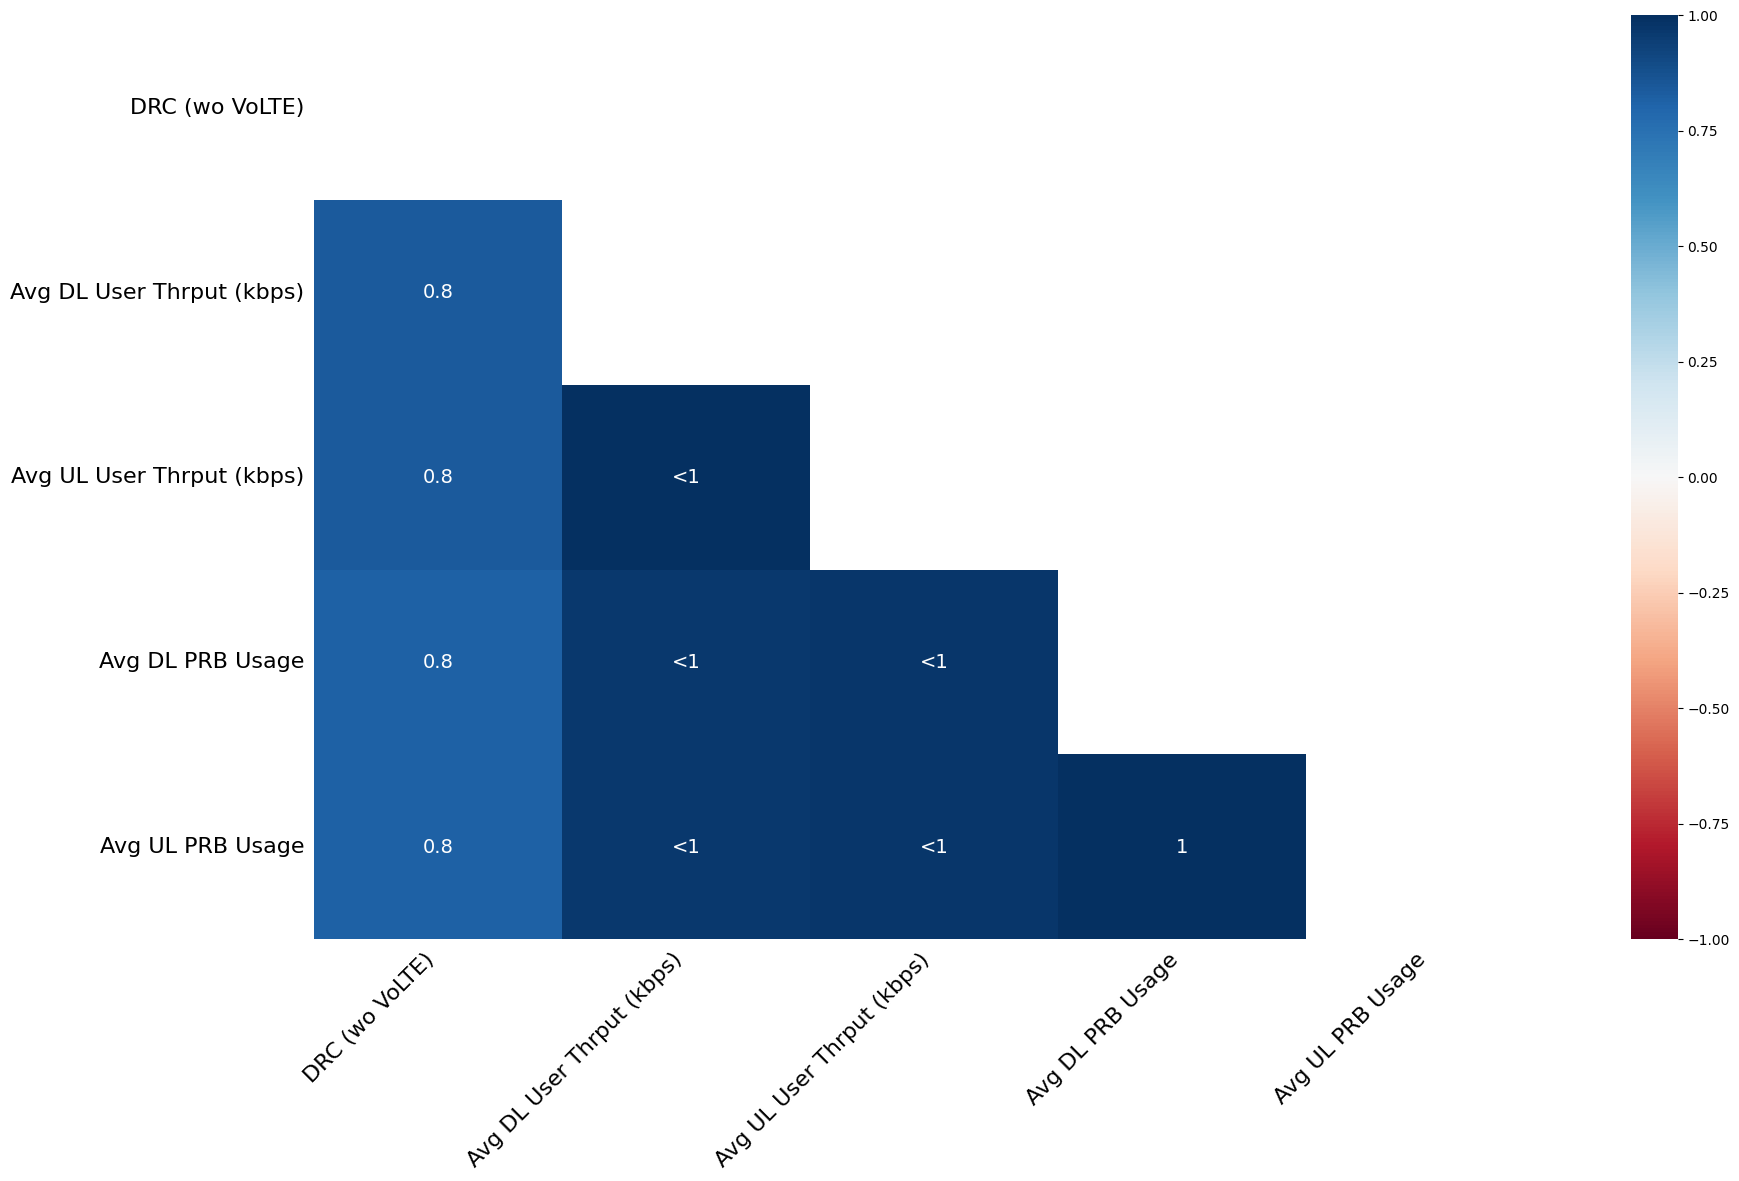

In [5]:
import missingno as msno

# Matrix & Heatmap to detect correlation of missingness between columns
msno.matrix(df)
msno.heatmap(df)

### Missing Types: Likely MNAR (Missing Not At Random)
Using domain knowledge, the missing values are from cells that are offline and not supposed to be recorded in the database

In [6]:
# % of missing values
df.isnull().mean().sort_values(ascending=False)

DRC (wo VoLTE)                0.009622
Avg DL User Thrput (kbps)     0.006893
Avg UL User Thrput (kbps)     0.006810
Avg UL PRB Usage              0.006421
Avg DL PRB Usage              0.006421
Date                          0.000000
eNodeB Name                   0.000000
Frequency band                0.000000
eNodeB Function Name          0.000000
Cell FDD TDD Indication       0.000000
Cell Name                     0.000000
Integrity                     0.000000
CSSR (wo VoLTE)               0.000000
LocalCell Id                  0.000000
UL Traffic Volume (GBytes)    0.000000
Avg DL Traffic Active User    0.000000
DL Traffic Volume (GBytes)    0.000000
Avg UL Traffic Active User    0.000000
Avg Traffic User              0.000000
dtype: float64

### Missing Values less than 1%

In [7]:
# Creating Missing Flags
df['DRC (wo VoLTE)_missing'] = df['DRC (wo VoLTE)'].isnull().astype(int)
df['Avg DL User Thrput (kbps)_missing'] = df['Avg DL User Thrput (kbps)'].isnull().astype(int)
df['Avg UL User Thrput (kbps)_missing'] = df['Avg UL User Thrput (kbps)'].isnull().astype(int)
df['Avg UL PRB Usage_missing'] = df['Avg UL PRB Usage'].isnull().astype(int)
df['Avg DL PRB Usage_missing'] = df['Avg DL PRB Usage'].isnull().astype(int)

In [8]:
# Replacing Missing Values with -1
df['DRC (wo VoLTE)'] = df['DRC (wo VoLTE)'].fillna(-1)
df['Avg DL User Thrput (kbps)'] = df['Avg DL User Thrput (kbps)'].fillna(-1)
df['Avg UL User Thrput (kbps)'] = df['Avg UL User Thrput (kbps)'].fillna(-1)
df['Avg UL PRB Usage'] = df['Avg UL PRB Usage'].fillna(-1)
df['Avg DL PRB Usage'] = df['Avg DL PRB Usage'].fillna(-1)

df.isnull().sum()

Date                                 0
eNodeB Name                          0
Frequency band                       0
Cell FDD TDD Indication              0
Cell Name                            0
LocalCell Id                         0
eNodeB Function Name                 0
Integrity                            0
CSSR (wo VoLTE)                      0
DRC (wo VoLTE)                       0
Avg DL User Thrput (kbps)            0
UL Traffic Volume (GBytes)           0
Avg UL User Thrput (kbps)            0
DL Traffic Volume (GBytes)           0
Avg DL Traffic Active User           0
Avg UL Traffic Active User           0
Avg DL PRB Usage                     0
Avg UL PRB Usage                     0
Avg Traffic User                     0
DRC (wo VoLTE)_missing               0
Avg DL User Thrput (kbps)_missing    0
Avg UL User Thrput (kbps)_missing    0
Avg UL PRB Usage_missing             0
Avg DL PRB Usage_missing             0
dtype: int64

In [9]:
df.drop_duplicates()

,Date,eNodeB Name,Frequency band,Cell FDD TDD Indication,Cell Name,LocalCell Id,eNodeB Function Name,Integrity,CSSR (wo VoLTE),DRC (wo VoLTE),...,Avg DL Traffic Active User,Avg UL Traffic Active User,Avg DL PRB Usage,Avg UL PRB Usage,Avg Traffic User,DRC (wo VoLTE)_missing,Avg DL User Thrput (kbps)_missing,Avg UL User Thrput (kbps)_missing,Avg UL PRB Usage_missing,Avg DL PRB Usage_missing
0,2024-06-24,0001_KKO_KATI_SRAN_FO_GE_GE,20,CELL_FDD,0001_KKO_KATI_3_L800,13,0001_KKO_KATI_4G,100%,99.153,0.9521,...,1.8903,1.5624,49.2775,15.0372,26.8633,0,0,0,0,0
1,2024-06-24,0001_KKO_KATI_SRAN_FO_GE_GE,20,CELL_FDD,0001_KKO_KATI_2_L800,12,0001_KKO_KATI_4G,100%,99.2467,0.7676,...,1.9331,1.7797,49.6515,16.8396,31.6133,0,0,0,0,0
2,2024-06-24,0001_KKO_KATI_SRAN_FO_GE_GE,20,CELL_FDD,0001_KKO_KATI_1_L800,11,0001_KKO_KATI_4G,100%,98.3222,0.8999,...,0.3966,0.4801,18.7620,7.9541,7.0259,0,0,0,0,0
3,2024-06-24,401_KAYES_SRAN_GE_GE,20,CELL_FDD,0401_KYS_KAY-LEGAL-SEGOU_3_L800,13,0401_KYS_KAY-LEGAL-SEGOU_4G,100%,99.6316,0.0715,...,0.6054,0.5256,26.4108,13.0305,11.9333,0,0,0,0,0
4,2024-06-24,401_KAYES_SRAN_GE_GE,20,CELL_FDD,0401_KYS_KAY-LEGAL-SEGOU_2_L800,12,0401_KYS_KAY-LEGAL-SEGOU_4G,100%,99.5652,0.1088,...,0.5842,0.3494,19.2749,9.9659,11.0457,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
637882,2025-06-16,5350_KKO_KATIBOUGOU_NA,20,CELL_FDD,5350_KKO_KATIBOUGOU-MEGUETAN_2_L800_NA,2,5350_KKO_KATIBOUGOU-MEGUETAN_4G_NA,15%,100,7.1304,...,0.0152,0.0158,5.8172,6.0960,0.7324,0,0,0,0,0
637883,2025-06-16,5350_KKO_KATIBOUGOU_NA,20,CELL_FDD,5350_KKO_KATIBOUGOU-MEGUETAN_1_L800_NA,1,5350_KKO_KATIBOUGOU-MEGUETAN_4G_NA,15%,99.0928,9.2664,...,0.0082,0.0091,3.3493,5.3675,0.3713,0,0,0,0,0
637884,2025-06-16,5344_KKO_SANANFARA_NA,28,CELL_FDD,5351_KKO_IPR-KATIBOUGOU_3_L700_NA,73,5344_KKO_KATI-SANANFARA_4G_NA,4%,99.7509,0.0000,...,0.1821,0.089,57.7976,12.4703,1.6685,0,0,0,0,0
637885,2025-06-16,5344_KKO_SANANFARA_NA,28,CELL_FDD,5344_KKO_KATI-SANANFARA_2_L700_NA,72,5344_KKO_KATI-SANANFARA_4G_NA,4%,99.8928,0.0000,...,0.0985,0.0553,41.6821,12.6493,1.6534,0,0,0,0,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 637887 entries, 0 to 637886
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               637887 non-null  object 
 1   eNodeB Name                        637887 non-null  object 
 2   Frequency band                     637887 non-null  int64  
 3   Cell FDD TDD Indication            637887 non-null  object 
 4   Cell Name                          637887 non-null  object 
 5   LocalCell Id                       637887 non-null  int64  
 6   eNodeB Function Name               637887 non-null  object 
 7   Integrity                          637887 non-null  object 
 8   CSSR (wo VoLTE)                    637887 non-null  object 
 9   DRC (wo VoLTE)                     637887 non-null  float64
 10  Avg DL User Thrput (kbps)          637887 non-null  float64
 11  UL Traffic Volume (GBytes)         6378

In [11]:
df.describe(include='all')

,Date,eNodeB Name,Frequency band,Cell FDD TDD Indication,Cell Name,LocalCell Id,eNodeB Function Name,Integrity,CSSR (wo VoLTE),DRC (wo VoLTE),...,Avg DL Traffic Active User,Avg UL Traffic Active User,Avg DL PRB Usage,Avg UL PRB Usage,Avg Traffic User,DRC (wo VoLTE)_missing,Avg DL User Thrput (kbps)_missing,Avg UL User Thrput (kbps)_missing,Avg UL PRB Usage_missing,Avg DL PRB Usage_missing
count,637887,637887,637887.000000,637887,637887,637887.000000,637887,637887,637887,637887.000000,...,637887.0,637887.0,637887.000000,637887.000000,637887.000000,637887.000000,637887.000000,637887.000000,637887.000000,637887.000000
unique,52,1732,NaN,2,13221,NaN,1732,101,26438,NaN,...,84805.0,67467.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2025-05-05,048BKO_CENTRE-COMMERCIAL_C11B,NaN,CELL_FDD,0418_KYS_SANDARE_3_L1800,NaN,0048_BKO_CENTRE-COMMERCIAL_4G,100%,/0,NaN,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,13131,1092,NaN,636951,52,NaN,1092,473338,6171,NaN,...,3468.0,3432.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,14.721926,NaN,NaN,28.155429,NaN,NaN,NaN,0.257729,...,NaN,NaN,23.348772,12.557938,18.730742,0.009622,0.006893,0.006810,0.006421,0.006421
std,NaN,NaN,9.626256,NaN,NaN,35.696111,NaN,NaN,NaN,0.435974,...,NaN,NaN,17.869578,7.793947,22.867266,0.097621,0.082738,0.082241,0.079875,0.079875
min,NaN,NaN,3.000000,NaN,NaN,1.000000,NaN,NaN,NaN,-1.000000,...,NaN,NaN,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,3.000000,NaN,NaN,4.000000,NaN,NaN,NaN,0.070300,...,NaN,NaN,9.881800,7.407900,4.334400,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,20.000000,NaN,NaN,11.000000,NaN,NaN,NaN,0.163500,...,NaN,NaN,18.794100,10.211600,11.039600,0.000000,0.000000,0.000000,0.000000,0.000000
75%,NaN,NaN,20.000000,NaN,NaN,71.000000,NaN,NaN,NaN,0.335200,...,NaN,NaN,31.979500,15.439000,25.064100,0.000000,0.000000,0.000000,0.000000,0.000000


In [12]:
df.columns = df.columns.str.strip().str.replace(r'[^\w]', '_', regex=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 637887 entries, 0 to 637886
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               637887 non-null  object 
 1   eNodeB_Name                        637887 non-null  object 
 2   Frequency_band                     637887 non-null  int64  
 3   Cell_FDD_TDD_Indication            637887 non-null  object 
 4   Cell_Name                          637887 non-null  object 
 5   LocalCell_Id                       637887 non-null  int64  
 6   eNodeB_Function_Name               637887 non-null  object 
 7   Integrity                          637887 non-null  object 
 8   CSSR__wo_VoLTE_                    637887 non-null  object 
 9   DRC__wo_VoLTE_                     637887 non-null  float64
 10  Avg_DL_User_Thrput__kbps_          637887 non-null  float64
 11  UL_Traffic_Volume__GBytes_         6378

In [13]:
# Converting Objec to String and Normalizing text fields
df['eNodeB_Name'] = df['eNodeB_Name'].astype('string')
df['eNodeB_Name'] = df['eNodeB_Name'].str.strip().str.replace(r'\s+', '', regex=True)
df['Cell_Name'] = df['Cell_Name'].astype('string')
df['Cell_Name'] = df['Cell_Name'].str.strip().str.replace(r'\s+', '', regex=True)
df['eNodeB_Function_Name'] = df['eNodeB_Function_Name'].astype('string')
df['eNodeB_Function_Name'] = df['eNodeB_Function_Name'].str.strip().str.replace(r'\s+', '', regex=True)
df['LocalCell_Id'] = df['LocalCell_Id'].astype('string')

In [14]:
# Converting Object to Category
df['Frequency_band'] = df['Frequency_band'].astype('category')
df['Cell_FDD_TDD_Indication'] = df['Cell_FDD_TDD_Indication'].astype('category')
df['LocalCell_Id'] = df['LocalCell_Id'].astype('category')
df['Integrity'] = df['Integrity'].astype('category')

In [15]:
import re

all_text = ''.join(df['CSSR__wo_VoLTE_'].dropna().astype(str))
special_chars = set(re.sub(r'[0-9, \-]', '', all_text))
print(special_chars)

{'/', '.'}


In [16]:
df['CSSR__wo_VoLTE_'] = df['CSSR__wo_VoLTE_'].str.replace('/', '', regex=False)

In [17]:
df.replace('NIL', pd.NA, inplace=True)

In [18]:
df.dropna(subset=['Avg_DL_Traffic_Active_User', 'Avg_UL_Traffic_Active_User'], inplace=True)
df.isnull().sum()

Date                                 0
eNodeB_Name                          0
Frequency_band                       0
Cell_FDD_TDD_Indication              0
Cell_Name                            0
LocalCell_Id                         0
eNodeB_Function_Name                 0
Integrity                            0
CSSR__wo_VoLTE_                      0
DRC__wo_VoLTE_                       0
Avg_DL_User_Thrput__kbps_            0
UL_Traffic_Volume__GBytes_           0
Avg_UL_User_Thrput__kbps_            0
DL_Traffic_Volume__GBytes_           0
Avg_DL_Traffic_Active_User           0
Avg_UL_Traffic_Active_User           0
Avg_DL_PRB_Usage                     0
Avg_UL_PRB_Usage                     0
Avg_Traffic_User                     0
DRC__wo_VoLTE__missing               0
Avg_DL_User_Thrput__kbps__missing    0
Avg_UL_User_Thrput__kbps__missing    0
Avg_UL_PRB_Usage_missing             0
Avg_DL_PRB_Usage_missing             0
dtype: int64

In [19]:
df['CSSR__wo_VoLTE_'] = pd.to_numeric(df['CSSR__wo_VoLTE_'])
df['DRC__wo_VoLTE_'] = pd.to_numeric(df['DRC__wo_VoLTE_'])
df['Avg_DL_User_Thrput__kbps_'] = pd.to_numeric(df['Avg_DL_User_Thrput__kbps_'])
df['UL_Traffic_Volume__GBytes_'] = pd.to_numeric(df['UL_Traffic_Volume__GBytes_'])
df['Avg_UL_User_Thrput__kbps_'] = pd.to_numeric(df['Avg_UL_User_Thrput__kbps_'])
df['DL_Traffic_Volume__GBytes_'] = pd.to_numeric(df['DL_Traffic_Volume__GBytes_'])
df['Avg_DL_Traffic_Active_User'] = pd.to_numeric(df['Avg_DL_Traffic_Active_User'])
df['Avg_UL_Traffic_Active_User'] = pd.to_numeric(df['Avg_UL_Traffic_Active_User'])
df['Avg_DL_PRB_Usage'] = pd.to_numeric(df['Avg_DL_PRB_Usage'])
df['Avg_UL_PRB_Usage'] = pd.to_numeric(df['Avg_UL_PRB_Usage'])
df['Avg_Traffic_User'] = pd.to_numeric(df['Avg_Traffic_User'])

In [20]:
# Converting Object to Category
df['Date'] = pd.to_datetime(df['Date'])

In [21]:
df['DRC__wo_VoLTE__missing'] = df['DRC__wo_VoLTE__missing'].astype(bool)
df['Avg_DL_User_Thrput__kbps__missing'] = df['Avg_DL_User_Thrput__kbps__missing'].astype(bool)
df['Avg_UL_User_Thrput__kbps__missing'] = df['Avg_UL_User_Thrput__kbps__missing'].astype(bool)
df['Avg_UL_PRB_Usage_missing'] = df['Avg_UL_PRB_Usage_missing'].astype(bool)
df['Avg_DL_PRB_Usage_missing'] = df['Avg_DL_PRB_Usage_missing'].astype(bool)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 637821 entries, 0 to 637886
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               637821 non-null  datetime64[ns]
 1   eNodeB_Name                        637821 non-null  string        
 2   Frequency_band                     637821 non-null  category      
 3   Cell_FDD_TDD_Indication            637821 non-null  category      
 4   Cell_Name                          637821 non-null  string        
 5   LocalCell_Id                       637821 non-null  category      
 6   eNodeB_Function_Name               637821 non-null  string        
 7   Integrity                          637821 non-null  category      
 8   CSSR__wo_VoLTE_                    637821 non-null  float64       
 9   DRC__wo_VoLTE_                     637821 non-null  float64       
 10  Avg_DL_User_Thrput__kbps_

In [22]:
df.describe(include='all')

,Date,eNodeB_Name,Frequency_band,Cell_FDD_TDD_Indication,Cell_Name,LocalCell_Id,eNodeB_Function_Name,Integrity,CSSR__wo_VoLTE_,DRC__wo_VoLTE_,...,Avg_DL_Traffic_Active_User,Avg_UL_Traffic_Active_User,Avg_DL_PRB_Usage,Avg_UL_PRB_Usage,Avg_Traffic_User,DRC__wo_VoLTE__missing,Avg_DL_User_Thrput__kbps__missing,Avg_UL_User_Thrput__kbps__missing,Avg_UL_PRB_Usage_missing,Avg_DL_PRB_Usage_missing
count,637821,637821,637821.0,637821,637821,637821,637821,637821,637821.000000,637821.000000,...,637821.000000,637821.000000,637821.000000,637821.000000,637821.000000,637821,637821,637821,637821,637821
unique,NaN,1732,5.0,2,13221,52,1732,101,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2
top,NaN,166BKO_GRAND-MARCHE_C11B,20.0,CELL_FDD,0418_KYS_SANDARE_3_L1800,6,0166_BKO_GRAND-MARCHE_4G,100%,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False
freq,NaN,1092,253078.0,636885,52,56111,1092,473338,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,631749,633490,633543,633791,633791
mean,2024-12-25 06:04:29.398467584,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.686260,0.257860,...,1.208207,0.821507,23.351292,12.559341,18.732680,NaN,NaN,NaN,NaN,NaN
min,2024-06-24 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,-1.000000,...,0.000000,0.000000,-1.000000,-1.000000,0.000000,NaN,NaN,NaN,NaN,NaN
25%,2024-09-23 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.595100,0.070400,...,0.153400,0.215400,9.884700,7.408500,4.335800,NaN,NaN,NaN,NaN,NaN
50%,2024-12-30 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.804100,0.163500,...,0.382300,0.494400,18.796400,10.212300,11.041600,NaN,NaN,NaN,NaN,NaN
75%,2025-03-24 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.899900,0.335200,...,0.873500,0.985000,31.981900,15.439900,25.066700,NaN,NaN,NaN,NaN,NaN
max,2025-06-16 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,33.333300,...,164.001700,122.455800,99.766100,89.555800,420.040600,NaN,NaN,NaN,NaN,NaN
